# PCA

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [2]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA as SklearnPCA

from models.pca import PCA

## Dataset

### Creation

In [3]:
# Creation
iris = load_iris()

X = iris.data
y = iris.target
target_names = iris.target_names
feature_names = iris.feature_names

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Scratch

In [4]:
scratch_pca = PCA(n_components=2)
X_pca = scratch_pca.fit_transform(X_scaled)

### `Sklearn`

In [6]:
sklearn_pca = SklearnPCA(n_components=2)
X_pca_sklearn = sklearn_pca.fit_transform(X_scaled)

### Results

In [7]:
print("Scratch explained variance:")
print(scratch_pca.explained_variance)

print()

print("Sklearn explained variance:")
print(sklearn_pca.explained_variance_)

Scratch explained variance:
[2.93808505 0.9201649 ]

Sklearn explained variance:
[2.93808505 0.9201649 ]


In [8]:
print("Scratch explained variance ratio:")
print(scratch_pca.explained_variance_ratio)

print()

print("Sklearn explained variance ratio:")
print(sklearn_pca.explained_variance_ratio_)

Scratch explained variance ratio:
[0.72962445 0.22850762]

Sklearn explained variance ratio:
[0.72962445 0.22850762]


## Plots

### Explained Variance

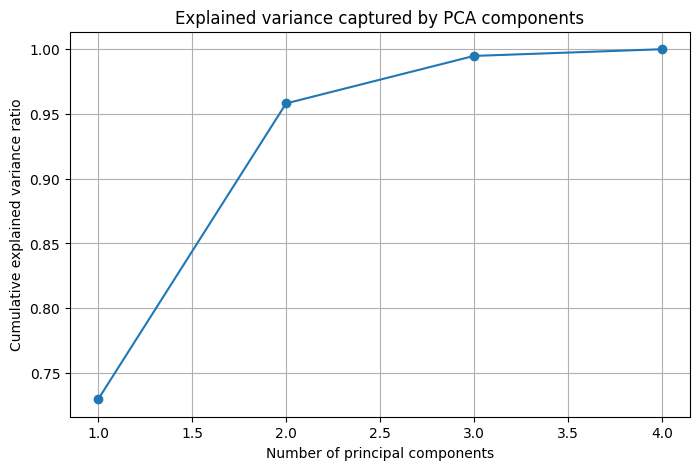

In [ ]:
full_pca = PCA(n_components=X_scaled.shape[1])
full_pca.fit(X_scaled)

plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(full_pca.explained_variance_ratio) + 1),
    np.cumsum(full_pca.explained_variance_ratio),
    marker="o",
)

plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance ratio")
plt.title("Explained variance captured by PCA components")
plt.grid(True)

plt.show()

### Projection

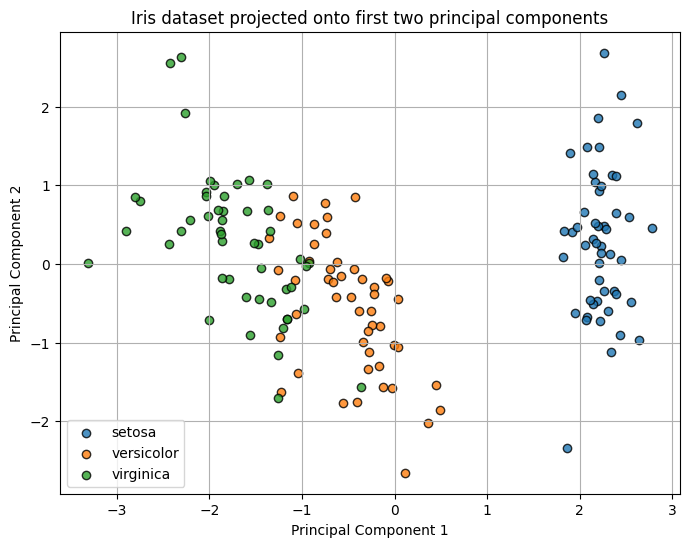

In [11]:
plt.figure(figsize=(8, 6))

for class_id, class_name in enumerate(target_names):
    mask = y == class_id

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=class_name,
        alpha=0.8,
        edgecolor="k",
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris dataset projected onto first two principal components")
plt.legend()
plt.grid(True)

plt.show()

## Principal Directions
I visualize the principal directions in the original feature space. The principal directions are the eigenvectors corresponding to the highest eigenvalues of the covariance matrix.

Since the original Iris dataset has four features and I chose to use 2 components, I get two vectors with 4 elements each. These elements, called *loadings*, indicate how strongly each original feature contributes to the corresponding principal component.

We can see that the first principal component (PC1) is dominated by the petal-related features, while the second principal component (PC2) is influenced primarily by sepal width. This helps explain why the first two principal components are able to separate the species so effectively.

In [13]:
loadings_df = pd.DataFrame(
    scratch_pca.components,
    columns=feature_names,
    index=["PC1", "PC2"]
)

loadings_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
PC1,-0.521066,0.269347,-0.580413,-0.564857
PC2,0.377418,0.923296,0.024492,0.066942


<Figure size 1000x400 with 0 Axes>

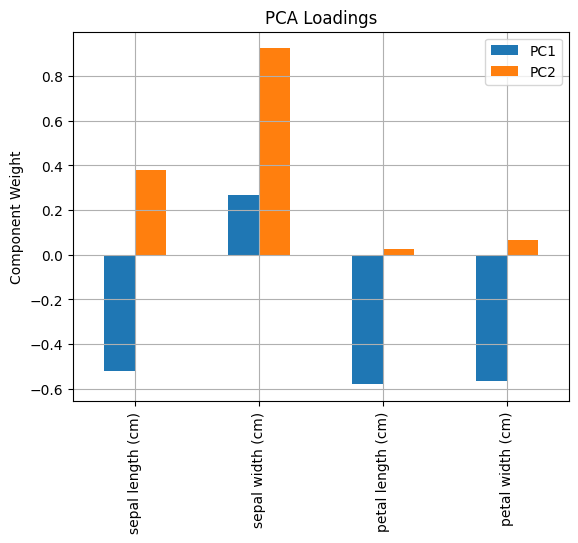

In [14]:
plt.figure(figsize=(10, 4))

loadings_df.T.plot(kind="bar")
plt.title("PCA Loadings")
plt.ylabel("Component Weight")
plt.grid(True)

plt.show()

## Reconstruction Error
We can see how much information was lost by reducing the dimensionality

In [15]:
X_proj = scratch_pca.transform(X_scaled)

X_reconstructed = (
    X_proj @ scratch_pca.components
    + scratch_pca.mean
)

mse = np.mean((X_scaled - X_reconstructed) ** 2)
print(mse)

0.041867927999983595
